In [ ]:
from google.colab import files

uploaded = files.upload()

Saving suppliers.csv to suppliers.csv
Saving stores.csv to stores.csv
Saving shipments.csv to shipments.csv
Saving categories.csv to categories.csv
Saving customers.csv to customers.csv
Saving employees.csv to employees.csv
Saving order_items.csv to order_items.csv
Saving orders.csv to orders.csv
Saving payments.csv to payments.csv
Saving products.csv to products.csv
Saving promotions.csv to promotions.csv
Saving returns.csv to returns.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
payments = pd.read_csv("payments.csv")
returns = pd.read_csv("returns.csv")
shipments = pd.read_csv("shipments.csv")
stores = pd.read_csv("stores.csv")
categories = pd.read_csv("categories.csv")
employees = pd.read_csv("employees.csv")
suppliers = pd.read_csv("suppliers.csv")
products = pd.read_csv("products.csv")
promotions = pd.read_csv("promotions.csv")

print("ALL DATASETS LOADED SUCCESSFULLY")

ALL DATASETS LOADED SUCCESSFULLY


In [ ]:
print("Customers    :", customers.shape)
print("Orders       :", orders.shape)
print("Order Items  :", order_items.shape)
print("Payments     :", payments.shape)
print("Returns      :", returns.shape)
print("Shipments    :", shipments.shape)
print("Stores       :", stores.shape)
print("Categories   :", categories.shape)
print("Employees    :", employees.shape)
print("Suppliers    :", suppliers.shape)
print("Products     :", products.shape)
print("Promotions   :", promotions.shape)

Customers    : (50000, 3)
Orders       : (300000, 5)
Order Items  : (600000, 5)
Payments     : (300000, 3)
Returns      : (30000, 3)
Shipments    : (300000, 3)
Stores       : (100, 2)
Categories   : (30, 2)
Employees    : (1000, 3)
Suppliers    : (200, 2)
Products     : (10000, 4)
Promotions   : (50, 2)


In [ ]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nORDERS")
print(orders.columns.tolist())

print("\nORDER ITEMS")
print(order_items.columns.tolist())

print("\nPAYMENTS")
print(payments.columns.tolist())

print("\nRETURNS")
print(returns.columns.tolist())

print("\nSHIPMENTS")
print(shipments.columns.tolist())

print("\nPRODUCTS")
print(products.columns.tolist())

print("\nPROMOTIONS")
print(promotions.columns.tolist())

CUSTOMERS
['customer_id', 'city', 'signup_date']

ORDERS
['order_id', 'customer_id', 'store_id', 'order_date', 'promotion_id']

ORDER ITEMS
['order_item_id', 'order_id', 'product_id', 'qty', 'price']

PAYMENTS
['payment_id', 'order_id', 'amount']

RETURNS
['return_id', 'order_item_id', 'refund']

SHIPMENTS
['shipment_id', 'order_id', 'status']

PRODUCTS
['product_id', 'category_id', 'supplier_id', 'price']

PROMOTIONS
['promotion_id', 'discount']


In [ ]:
# STEP 6: CHECK DATA QUALITY

datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Returns": returns,
    "Shipments": shipments,
    "Products": products,
    "Promotions": promotions
}

for name, df in datasets.items():
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:", df.duplicated().sum())




Customers

Data Types:
customer_id     int64
city           object
signup_date    object
dtype: object

Missing Values:
customer_id    0
city           0
signup_date    0
dtype: int64

Duplicate Rows: 0

Orders

Data Types:
order_id         int64
customer_id      int64
store_id         int64
order_date      object
promotion_id     int64
dtype: object

Missing Values:
order_id        0
customer_id     0
store_id        0
order_date      0
promotion_id    0
dtype: int64

Duplicate Rows: 0

Order Items

Data Types:
order_item_id    int64
order_id         int64
product_id       int64
qty              int64
price            int64
dtype: object

Missing Values:
order_item_id    0
order_id         0
product_id       0
qty              0
price            0
dtype: int64

Duplicate Rows: 0

Payments

Data Types:
payment_id    int64
order_id      int64
amount        int64
dtype: object

Missing Values:
payment_id    0
order_id      0
amount        0
dtype: int64

Duplicate Rows: 0

Returns

Data

In [ ]:
# STEP 7: CONVERT DATE COLUMNS

customers["signup_date"] = pd.to_datetime(customers["signup_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])

print("Date conversion completed successfully!")

print("\nCustomers signup_date:")
print(customers["signup_date"].dtype)

print("\nOrders order_date:")
print(orders["order_date"].dtype)

print("\nCustomer date range:")
print(customers["signup_date"].min(), "to", customers["signup_date"].max())

print("\nOrder date range:")
print(orders["order_date"].min(), "to", orders["order_date"].max())

Date conversion completed successfully!

Customers signup_date:
datetime64[ns]

Orders order_date:
datetime64[ns]

Customer date range:
2019-01-01 00:00:00 to 2024-01-01 00:00:00

Order date range:
2020-01-01 00:00:00 to 2024-01-01 00:00:00


In [ ]:
# STEP 8: CREATE CUSTOMER ORDER SUMMARY

customer_orders = orders.groupby("customer_id").agg(
    total_orders=("order_id", "nunique"),
    first_order_date=("order_date", "min"),
    last_order_date=("order_date", "max")
).reset_index()

# Calculate total spending from order items
order_revenue = order_items.assign(
    revenue=order_items["qty"] * order_items["price"]
).groupby("order_id")["revenue"].sum().reset_index()

# Connect revenue to customers
customer_revenue = orders[["order_id", "customer_id"]].merge(
    order_revenue,
    on="order_id",
    how="left"
).groupby("customer_id")["revenue"].sum().reset_index()

# Combine everything
customer_summary = customers.merge(
    customer_orders,
    on="customer_id",
    how="left"
).merge(
    customer_revenue,
    on="customer_id",
    how="left"
)

# Customers with no orders
customer_summary["total_orders"] = customer_summary["total_orders"].fillna(0)
customer_summary["revenue"] = customer_summary["revenue"].fillna(0)

print("Customer summary created successfully!")
print("\nShape:", customer_summary.shape)

print("\nFirst 10 rows:")
print(customer_summary.head(10))

Customer summary created successfully!

Shape: (50000, 7)

First 10 rows:
   customer_id       city signup_date  total_orders first_order_date  \
0            1     Mumbai  2021-02-16           5.0       2020-04-17   
1            2  Bangalore  2019-06-22           6.0       2020-04-29   
2            3       Pune  2022-01-25           6.0       2020-04-30   
3            4     Mumbai  2023-06-14           2.0       2020-11-15   
4            5      Delhi  2023-06-24           4.0       2021-08-10   
5            6  Bangalore  2022-03-07           5.0       2020-02-28   
6            7      Delhi  2021-07-18           4.0       2021-11-21   
7            8  Bangalore  2021-03-29          10.0       2020-05-28   
8            9     Mumbai  2019-09-06           4.0       2020-09-05   
9           10  Bangalore  2022-05-25           5.0       2021-08-02   

  last_order_date   revenue  
0      2023-08-24   53505.0  
1      2022-12-28  122774.0  
2      2023-04-19   41902.0  
3      2021-0

In [ ]:
# STEP 9: CREATE CUSTOMER COHORT

customer_summary["cohort_month"] = (
    customer_summary["signup_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print("Cohort creation completed!")

print("\nNumber of customers in each cohort:")
print(
    customer_summary["cohort_month"]
    .value_counts()
    .sort_index()
)

print("\nFirst 10 customers with their cohorts:")
print(
    customer_summary[
        ["customer_id", "signup_date", "cohort_month"]
    ].head(10)
)

Cohort creation completed!

Number of customers in each cohort:
cohort_month
2019-01-01    834
2019-02-01    729
2019-03-01    877
2019-04-01    780
2019-05-01    833
             ... 
2023-09-01    794
2023-10-01    865
2023-11-01    818
2023-12-01    851
2024-01-01     29
Name: count, Length: 61, dtype: int64

First 10 customers with their cohorts:
   customer_id signup_date cohort_month
0            1  2021-02-16   2021-02-01
1            2  2019-06-22   2019-06-01
2            3  2022-01-25   2022-01-01
3            4  2023-06-14   2023-06-01
4            5  2023-06-24   2023-06-01
5            6  2022-03-07   2022-03-01
6            7  2021-07-18   2021-07-01
7            8  2021-03-29   2021-03-01
8            9  2019-09-06   2019-09-01
9           10  2022-05-25   2022-05-01


In [ ]:
# STEP 10: CREATE CUSTOMER ACTIVITY TABLE

customer_activity = orders[
    ["customer_id", "order_id", "order_date"]
].copy()

# Convert order date to month
customer_activity["order_month"] = (
    customer_activity["order_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Add customer's cohort month
customer_activity = customer_activity.merge(
    customer_summary[
        ["customer_id", "cohort_month"]
    ],
    on="customer_id",
    how="left"
)

print("Customer activity table created successfully!")

print("\nShape:", customer_activity.shape)

print("\nFirst 10 rows:")
print(customer_activity.head(10))

print("\nUnique customers:", customer_activity["customer_id"].nunique())
print("Unique orders:", customer_activity["order_id"].nunique())
print("Unique order months:", customer_activity["order_month"].nunique())

Customer activity table created successfully!

Shape: (300000, 5)

First 10 rows:
   customer_id  order_id order_date order_month cohort_month
0        45308         1 2021-08-26  2021-08-01   2019-06-01
1        10070         2 2022-03-19  2022-03-01   2019-10-01
2        43308         3 2021-01-21  2021-01-01   2022-05-01
3        47997         4 2021-01-16  2021-01-01   2022-11-01
4        36546         5 2022-09-14  2022-09-01   2023-06-01
5         9479         6 2023-02-03  2023-02-01   2022-07-01
6        33431         7 2022-10-29  2022-10-01   2023-06-01
7        33130         8 2022-10-10  2022-10-01   2019-08-01
8        39339         9 2021-07-09  2021-07-01   2022-03-01
9        28094        10 2022-06-03  2022-06-01   2022-02-01

Unique customers: 49886
Unique orders: 300000
Unique order months: 49


In [ ]:
# STEP 11: CHECK FOR ORDERS BEFORE CUSTOMER SIGNUP

customer_activity["before_signup"] = (
    customer_activity["order_date"] <
    customer_activity["cohort_month"]
)

before_signup_count = customer_activity["before_signup"].sum()

print("Orders before customer's signup month:", before_signup_count)

print(
    "Percentage of all orders:",
    round(before_signup_count / len(customer_activity) * 100, 2),
    "%"
)

print("\nExample records:")
print(
    customer_activity[
        customer_activity["before_signup"]
    ].head(10)
)

Orders before customer's signup month: 117666
Percentage of all orders: 39.22 %

Example records:
    customer_id  order_id order_date order_month cohort_month  before_signup
2         43308         3 2021-01-21  2021-01-01   2022-05-01           True
3         47997         4 2021-01-16  2021-01-01   2022-11-01           True
4         36546         5 2022-09-14  2022-09-01   2023-06-01           True
6         33431         7 2022-10-29  2022-10-01   2023-06-01           True
8         39339         9 2021-07-09  2021-07-01   2022-03-01           True
10        26670        11 2021-04-26  2021-04-01   2023-01-01           True
15        24181        16 2023-05-31  2023-05-01   2023-11-01           True
16        39062        17 2022-02-03  2022-02-01   2023-03-01           True
20        38754        21 2020-11-14  2020-11-01   2023-01-01           True
21        13747        22 2021-01-30  2021-01-01   2021-05-01           True


In [ ]:
# STEP 12: CLEAN CUSTOMER ACTIVITY FOR COHORT ANALYSIS

cohort_activity = customer_activity[
    customer_activity["order_month"] >= customer_activity["cohort_month"]
].copy()

# Remove the temporary quality-check column
cohort_activity = cohort_activity.drop(columns=["before_signup"])

print("Clean cohort activity table created!")

print("\nOriginal orders:", len(customer_activity))
print("Valid cohort orders:", len(cohort_activity))
print("Excluded pre-signup orders:",
      len(customer_activity) - len(cohort_activity))

print("\nPercentage of orders retained:",
      round(len(cohort_activity) / len(customer_activity) * 100, 2),
      "%")

print("\nUnique customers in cohort activity:",
      cohort_activity["customer_id"].nunique())

print("\nFirst 10 rows:")
print(cohort_activity.head(10))

Clean cohort activity table created!

Original orders: 300000
Valid cohort orders: 182334
Excluded pre-signup orders: 117666

Percentage of orders retained: 60.78 %

Unique customers in cohort activity: 43747

First 10 rows:
    customer_id  order_id order_date order_month cohort_month
0         45308         1 2021-08-26  2021-08-01   2019-06-01
1         10070         2 2022-03-19  2022-03-01   2019-10-01
5          9479         6 2023-02-03  2023-02-01   2022-07-01
7         33130         8 2022-10-10  2022-10-01   2019-08-01
9         28094        10 2022-06-03  2022-06-01   2022-02-01
11         7224        12 2023-01-05  2023-01-01   2020-02-01
12        46135        13 2023-06-14  2023-06-01   2022-02-01
13        39033        14 2022-03-08  2022-03-01   2019-11-01
14        20101        15 2022-08-06  2022-08-01   2019-10-01
17        22043        18 2020-04-27  2020-04-01   2019-02-01


In [ ]:
# STEP 13: CALCULATE COHORT INDEX

cohort_activity["cohort_index"] = (
    (cohort_activity["order_month"].dt.year -
     cohort_activity["cohort_month"].dt.year) * 12
    +
    (cohort_activity["order_month"].dt.month -
     cohort_activity["cohort_month"].dt.month)
)

print("Cohort index calculated successfully!")

print("\nCohort index distribution:")
print(
    cohort_activity["cohort_index"]
    .value_counts()
    .sort_index()
    .head(25)
)

print("\nSample records:")
print(
    cohort_activity[
        [
            "customer_id",
            "order_month",
            "cohort_month",
            "cohort_index"
        ]
    ].head(15)
)

Cohort index calculated successfully!

Cohort index distribution:
cohort_index
0     4885
1     5002
2     5087
3     5045
4     5018
5     5091
6     5038
7     4935
8     5062
9     4922
10    5118
11    5030
12    4920
13    4813
14    4736
15    4691
16    4598
17    4422
18    4335
19    4301
20    4180
21    4033
22    3926
23    3927
24    3722
Name: count, dtype: int64

Sample records:
    customer_id order_month cohort_month  cohort_index
0         45308  2021-08-01   2019-06-01            26
1         10070  2022-03-01   2019-10-01            29
5          9479  2023-02-01   2022-07-01             7
7         33130  2022-10-01   2019-08-01            38
9         28094  2022-06-01   2022-02-01             4
11         7224  2023-01-01   2020-02-01            35
12        46135  2023-06-01   2022-02-01            16
13        39033  2022-03-01   2019-11-01            28
14        20101  2022-08-01   2019-10-01            34
17        22043  2020-04-01   2019-02-01            1

In [ ]:
# STEP 14: BUILD COHORT RETENTION TABLE

# Count unique active customers for each cohort and month
cohort_counts = (
    cohort_activity
    .groupby(["cohort_month", "cohort_index"])["customer_id"]
    .nunique()
    .reset_index()
)

# Convert the data into a retention matrix
retention_matrix = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

print("Cohort customer count matrix created!")

print("\nRetention matrix shape:", retention_matrix.shape)

print("\nFirst 10 cohorts:")
print(retention_matrix.head(10))

Cohort customer count matrix created!

Retention matrix shape: (61, 61)

First 10 cohorts:
cohort_index  0   1   2     3      4      5      6      7      8      9   ...  \
cohort_month                                                              ...   
2019-01-01   NaN NaN NaN   NaN    NaN    NaN    NaN    NaN    NaN    NaN  ...   
2019-02-01   NaN NaN NaN   NaN    NaN    NaN    NaN    NaN    NaN    NaN  ...   
2019-03-01   NaN NaN NaN   NaN    NaN    NaN    NaN    NaN    NaN    NaN  ...   
2019-04-01   NaN NaN NaN   NaN    NaN    NaN    NaN    NaN    NaN   94.0  ...   
2019-05-01   NaN NaN NaN   NaN    NaN    NaN    NaN    NaN  103.0   94.0  ...   
2019-06-01   NaN NaN NaN   NaN    NaN    NaN    NaN   94.0  102.0  108.0  ...   
2019-07-01   NaN NaN NaN   NaN    NaN    NaN  128.0   99.0  121.0  101.0  ...   
2019-08-01   NaN NaN NaN   NaN    NaN  100.0   95.0  104.0  105.0  103.0  ...   
2019-09-01   NaN NaN NaN   NaN   94.0   84.0   78.0   96.0   88.0   80.0  ...   
2019-10-01   NaN N

In [ ]:
# STEP 15: CREATE PURCHASE-BASED COHORTS

# Find each customer's first valid purchase month
first_purchase = (
    cohort_activity
    .groupby("customer_id")["order_month"]
    .min()
    .reset_index()
    .rename(columns={"order_month": "cohort_month"})
)

# Replace the cohort with the customer's first purchase month
cohort_activity = cohort_activity.drop(
    columns=["cohort_month"]
).merge(
    first_purchase,
    on="customer_id",
    how="left"
)

# Recalculate cohort index
cohort_activity["cohort_index"] = (
    (cohort_activity["order_month"].dt.year -
     cohort_activity["cohort_month"].dt.year) * 12
    +
    (cohort_activity["order_month"].dt.month -
     cohort_activity["cohort_month"].dt.month)
)

print("Purchase-based cohorts created successfully!")

print("\nUnique customers:", cohort_activity["customer_id"].nunique())

print("\nCohort index distribution:")
print(
    cohort_activity["cohort_index"]
    .value_counts()
    .sort_index()
    .head(25)
)

print("\nSample:")
print(
    cohort_activity[
        [
            "customer_id",
            "order_month",
            "cohort_month",
            "cohort_index"
        ]
    ].head(10)
)

Purchase-based cohorts created successfully!

Unique customers: 43747

Cohort index distribution:
cohort_index
0     46475
1      5411
2      5366
3      5151
4      5057
5      4850
6      4824
7      4726
8      4602
9      4507
10     4373
11     4312
12     4175
13     4106
14     3989
15     3803
16     3881
17     3780
18     3569
19     3524
20     3462
21     3162
22     3129
23     3009
24     2936
Name: count, dtype: int64

Sample:
   customer_id order_month cohort_month  cohort_index
0        45308  2021-08-01   2020-02-01            18
1        10070  2022-03-01   2020-10-01            17
2         9479  2023-02-01   2023-02-01             0
3        33130  2022-10-01   2020-12-01            22
4        28094  2022-06-01   2022-06-01             0
5         7224  2023-01-01   2022-10-01             3
6        46135  2023-06-01   2022-11-01             7
7        39033  2022-03-01   2020-01-01            26
8        20101  2022-08-01   2020-03-01            29
9        22043

In [ ]:
# STEP 16: BUILD CUSTOMER RETENTION MATRIX

# Count unique customers active in each cohort month
cohort_counts = (
    cohort_activity
    .groupby(["cohort_month", "cohort_index"])["customer_id"]
    .nunique()
    .reset_index()
)

# Create matrix
retention_counts = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

# Convert customer counts into retention percentages
retention_percentage = retention_counts.div(
    retention_counts[0],
    axis=0
) * 100

print("Retention matrix created successfully!")

print("\nMatrix shape:", retention_percentage.shape)

print("\nFirst 10 cohorts:")
print(
    retention_percentage.iloc[:10, :13].round(2)
)

Retention matrix created successfully!

Matrix shape: (49, 49)

First 10 cohorts:
cohort_index     0      1      2      3      4      5      6      7      8   \
cohort_month                                                                  
2020-01-01    100.0  10.84  14.13  11.51  11.66  10.39  12.63  12.93  10.84   
2020-02-01    100.0  12.62  12.36  12.70  11.17  12.53  11.25  11.76  11.76   
2020-03-01    100.0  12.35  13.40  11.73  11.65  10.95  11.38  13.13  10.25   
2020-04-01    100.0  10.71   9.43  12.18  11.54  11.45  10.53  10.71  12.82   
2020-05-01    100.0  11.76  11.85  10.55  12.63  12.02  11.33  13.32  14.36   
2020-06-01    100.0  12.36  11.79  11.60  10.93  12.17  13.78  11.98   9.79   
2020-07-01    100.0  13.01  11.70  13.48  12.27  11.52  12.64  12.27  13.11   
2020-08-01    100.0  12.66  12.08  10.82  13.04   9.86   9.57  12.17  12.85   
2020-09-01    100.0  11.15  11.36  11.36   9.67  10.62  13.04  11.36  10.52   
2020-10-01    100.0  11.53  13.27  11.73  10.31  

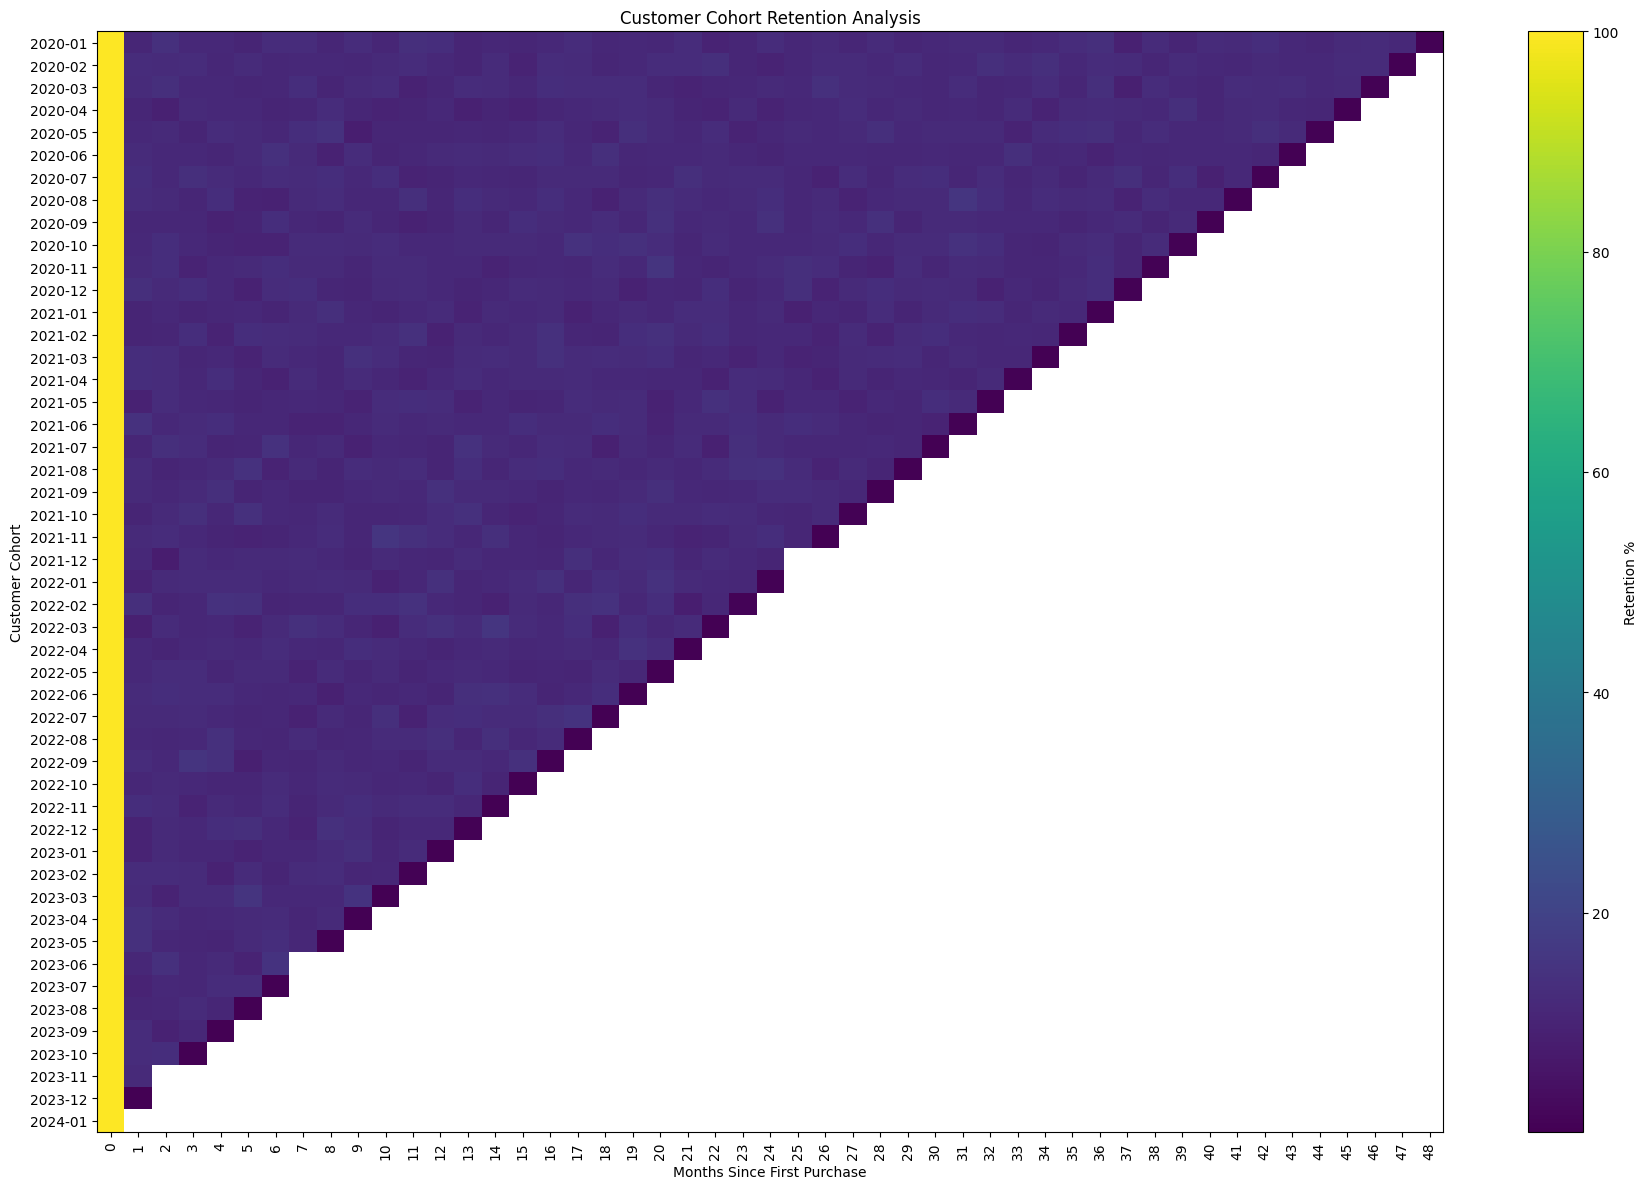

In [ ]:
# STEP 17: CREATE COHORT RETENTION HEATMAP

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))

plt.imshow(
    retention_percentage,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Retention %")

plt.title("Customer Cohort Retention Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")

# Show cohort labels
plt.yticks(
    range(len(retention_percentage.index)),
    retention_percentage.index.strftime("%Y-%m")
)

# Show every 3rd month on x-axis
x_labels = retention_percentage.columns
plt.xticks(
    range(len(x_labels)),
    x_labels,
    rotation=90
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 18: CALCULATE KEY RETENTION KPIs

retention_kpis = pd.DataFrame({
    "Metric": [
        "M0 Retention",
        "M1 Retention",
        "M3 Retention",
        "M6 Retention",
        "M12 Retention"
    ],
    "Retention (%)": [
        retention_percentage[0].dropna().mean(),
        retention_percentage[1].dropna().mean(),
        retention_percentage[3].dropna().mean(),
        retention_percentage[6].dropna().mean(),
        retention_percentage[12].dropna().mean()
    ]
})

retention_kpis["Retention (%)"] = retention_kpis["Retention (%)"].round(2)

print("KEY RETENTION KPIs")
print("=" * 40)
print(retention_kpis.to_string(index=False))

print("\nNumber of cohorts used:")
print("M0 :", retention_percentage[0].dropna().count())
print("M1 :", retention_percentage[1].dropna().count())
print("M3 :", retention_percentage[3].dropna().count())
print("M6 :", retention_percentage[6].dropna().count())
print("M12:", retention_percentage[12].dropna().count())

KEY RETENTION KPIs
       Metric  Retention (%)
 M0 Retention         100.00
 M1 Retention          11.58
 M3 Retention          11.56
 M6 Retention          11.47
M12 Retention          11.43

Number of cohorts used:
M0 : 49
M1 : 48
M3 : 46
M6 : 43
M12: 37


In [ ]:
# STEP 19: DEFINE CUSTOMER CHURN

# Latest order date in the dataset
analysis_date = orders["order_date"].max()

# Calculate days since each customer's last purchase
customer_summary["days_since_last_order"] = (
    analysis_date - customer_summary["last_order_date"]
).dt.days

# Define churn
customer_summary["churned"] = (
    customer_summary["days_since_last_order"] > 90
)

# Create readable churn status
customer_summary["churn_status"] = np.where(
    customer_summary["churned"],
    "Churned",
    "Active"
)

print("Churn analysis created successfully!")

print("\nAnalysis date:", analysis_date)

print("\nChurn summary:")
print(
    customer_summary["churn_status"]
    .value_counts()
)

print("\nChurn percentage:")
print(
    round(
        customer_summary["churned"].mean() * 100,
        2
    ),
    "%"
)

print("\nAverage days since last order:",
      round(customer_summary["days_since_last_order"].mean(), 2))

Churn analysis created successfully!

Analysis date: 2024-01-01 00:00:00

Churn summary:
churn_status
Churned    34320
Active     15680
Name: count, dtype: int64

Churn percentage:
68.64 %

Average days since last order: 239.48


In [ ]:
# STEP 20: CHURN ANALYSIS BY CITY

churn_by_city = (
    customer_summary
    .groupby("city")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        average_days_since_order=("days_since_last_order", "mean")
    )
    .reset_index()
)

# Calculate churn rate
churn_by_city["churn_rate"] = (
    churn_by_city["churned_customers"]
    / churn_by_city["total_customers"]
    * 100
)

# Round values
churn_by_city["churn_rate"] = churn_by_city["churn_rate"].round(2)
churn_by_city["average_days_since_order"] = (
    churn_by_city["average_days_since_order"].round(1)
)

# Sort by highest churn rate
churn_by_city = churn_by_city.sort_values(
    "churn_rate",
    ascending=False
)

print("CHURN BY CITY")
print("=" * 60)

print(
    churn_by_city.to_string(index=False)
)

CHURN BY CITY
     city  total_customers  churned_customers  average_days_since_order  churn_rate
   Mumbai            12656               8738                     241.3       69.04
     Pune            12521               8610                     239.3       68.76
    Delhi            12389               8481                     241.5       68.46
Bangalore            12434               8491                     235.8       68.29


In [ ]:
# STEP 21: CHURN BY CUSTOMER VALUE

# Create 4 customer value groups based on revenue
customer_summary["value_segment"] = pd.qcut(
    customer_summary["revenue"],
    q=4,
    labels=[
        "Q1 - Low Value",
        "Q2 - Medium-Low",
        "Q3 - Medium-High",
        "Q4 - High Value"
    ]
)

# Calculate churn by value segment
churn_by_value = (
    customer_summary
    .groupby("value_segment", observed=False)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        average_revenue=("revenue", "mean")
    )
    .reset_index()
)

# Calculate churn rate
churn_by_value["churn_rate"] = (
    churn_by_value["churned_customers"]
    / churn_by_value["total_customers"]
    * 100
)

# Round results
churn_by_value["average_revenue"] = (
    churn_by_value["average_revenue"].round(2)
)

churn_by_value["churn_rate"] = (
    churn_by_value["churn_rate"].round(2)
)

print("CHURN BY CUSTOMER VALUE")
print("=" * 70)

print(churn_by_value.to_string(index=False))

CHURN BY CUSTOMER VALUE
   value_segment  total_customers  churned_customers  average_revenue  churn_rate
  Q1 - Low Value            12500               9788         28627.11       78.30
 Q2 - Medium-Low            12500               8963         58715.86       71.70
Q3 - Medium-High            12500               8244         85685.09       65.95
 Q4 - High Value            12500               7325        133191.63       58.60


In [ ]:
# STEP 22: CHURN BY ORDER FREQUENCY

# Create order frequency segments
customer_summary["order_frequency_segment"] = pd.cut(
    customer_summary["total_orders"],
    bins=[0, 1, 3, 6, float("inf")],
    labels=[
        "1 Order",
        "2-3 Orders",
        "4-6 Orders",
        "7+ Orders"
    ]
)

# Calculate churn by order frequency
churn_by_frequency = (
    customer_summary
    .groupby("order_frequency_segment", observed=False)
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        average_orders=("total_orders", "mean"),
        average_revenue=("revenue", "mean")
    )
    .reset_index()
)

# Calculate churn rate
churn_by_frequency["churn_rate"] = (
    churn_by_frequency["churned_customers"]
    / churn_by_frequency["total_customers"]
    * 100
)

# Round values
churn_by_frequency["average_orders"] = (
    churn_by_frequency["average_orders"].round(2)
)

churn_by_frequency["average_revenue"] = (
    churn_by_frequency["average_revenue"].round(2)
)

churn_by_frequency["churn_rate"] = (
    churn_by_frequency["churn_rate"].round(2)
)

print("CHURN BY ORDER FREQUENCY")
print("=" * 75)

print(churn_by_frequency.to_string(index=False))

CHURN BY ORDER FREQUENCY
order_frequency_segment  total_customers  churned_customers  average_orders  average_revenue  churn_rate
                1 Order              718                671            1.00         13372.37       93.45
             2-3 Orders             6815               5757            2.67         34265.74       84.48
             4-6 Orders            22690              16420            5.05         64520.50       72.37
              7+ Orders            19663              11472            8.46        107849.95       58.34


In [ ]:
# STEP 23: CUSTOMER CHURN RISK SEGMENTATION

customer_summary["risk_segment"] = pd.cut(
    customer_summary["days_since_last_order"],
    bins=[-1, 90, 180, float("inf")],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

# Summarize risk segments
risk_summary = (
    customer_summary
    .groupby("risk_segment", observed=False)
    .agg(
        customers=("customer_id", "count"),
        average_orders=("total_orders", "mean"),
        average_revenue=("revenue", "mean")
    )
    .reset_index()
)

risk_summary["customer_percentage"] = (
    risk_summary["customers"]
    / len(customer_summary)
    * 100
)

risk_summary["average_orders"] = (
    risk_summary["average_orders"].round(2)
)

risk_summary["average_revenue"] = (
    risk_summary["average_revenue"].round(2)
)

risk_summary["customer_percentage"] = (
    risk_summary["customer_percentage"].round(2)
)

print("CUSTOMER RISK SEGMENTATION")
print("=" * 75)

print(risk_summary.to_string(index=False))

CUSTOMER RISK SEGMENTATION
risk_segment  customers  average_orders  average_revenue  customer_percentage
    Low Risk      15566            6.84         87222.84                31.13
 Medium Risk      10617            6.45         82280.17                21.23
   High Risk      23703            5.28         67352.95                47.41


In [ ]:
# STEP 24: HIGH-VALUE CUSTOMERS AT RISK

customer_summary["value_segment"] = pd.qcut(
    customer_summary["revenue"],
    q=4,
    labels=["Low Value", "Medium-Low Value", "Medium-High Value", "High Value"]
)

high_value_risk = customer_summary[
    (customer_summary["value_segment"] == "High Value") &
    (customer_summary["risk_segment"] == "High Risk")
].copy()

print("=" * 75)
print("HIGH-VALUE CUSTOMERS AT HIGH RISK OF CHURN")
print("=" * 75)

print(f"Customers: {len(high_value_risk):,}")
print(f"Average Revenue: ₹{high_value_risk['revenue'].mean():,.2f}")
print(f"Average Orders: {high_value_risk['total_orders'].mean():.2f}")
print(f"Average Days Since Last Order: {high_value_risk['days_since_last_order'].mean():.0f}")

print("\nTop 10 High-Value Customers at Risk:")
print(
    high_value_risk[
        ["customer_id", "city", "revenue", "total_orders", "days_since_last_order"]
    ]
    .sort_values("revenue", ascending=False)
    .head(10)
    .to_string(index=False)
)

HIGH-VALUE CUSTOMERS AT HIGH RISK OF CHURN
Customers: 4,208
Average Revenue: ₹129,968.30
Average Orders: 7.90
Average Days Since Last Order: 331

Top 10 High-Value Customers at Risk:
 customer_id      city  revenue  total_orders  days_since_last_order
       30723     Delhi 284477.0          10.0                  217.0
       13511     Delhi 284287.0          14.0                  433.0
       13527 Bangalore 282044.0          15.0                  226.0
       20912    Mumbai 280589.0          11.0                  254.0
       16262    Mumbai 271202.0          12.0                  218.0
       20639      Pune 263702.0          13.0                  223.0
       40208      Pune 252072.0          10.0                  325.0
       17943    Mumbai 248376.0          11.0                  370.0
        6945      Pune 247531.0          12.0                  186.0
       15944 Bangalore 241265.0          11.0                  367.0


In [ ]:
# STEP 25: CUSTOMER VALUE × CHURN RISK MATRIX

customer_summary["value_segment"] = pd.qcut(
    customer_summary["revenue"],
    q=4,
    labels=["Low Value", "Medium-Low Value", "Medium-High Value", "High Value"]
)

customer_summary["risk_segment"] = pd.cut(
    customer_summary["days_since_last_order"],
    bins=[-1, 90, 180, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

value_risk_matrix = pd.crosstab(
    customer_summary["value_segment"],
    customer_summary["risk_segment"]
)

print("=" * 75)
print("CUSTOMER VALUE × CHURN RISK MATRIX")
print("=" * 75)
print(value_risk_matrix)

print("\nPercentage of Total Customers:")
value_risk_percentage = (
    value_risk_matrix / len(customer_summary) * 100
).round(2)

print(value_risk_percentage)

CUSTOMER VALUE × CHURN RISK MATRIX
risk_segment       Low Risk  Medium Risk  High Risk
value_segment                                      
Low Value              2598         2084       7704
Medium-Low Value       3537         2627       6336
Medium-High Value      4256         2789       5455
High Value             5175         3117       4208

Percentage of Total Customers:
risk_segment       Low Risk  Medium Risk  High Risk
value_segment                                      
Low Value              5.20         4.17      15.41
Medium-Low Value       7.07         5.25      12.67
Medium-High Value      8.51         5.58      10.91
High Value            10.35         6.23       8.42


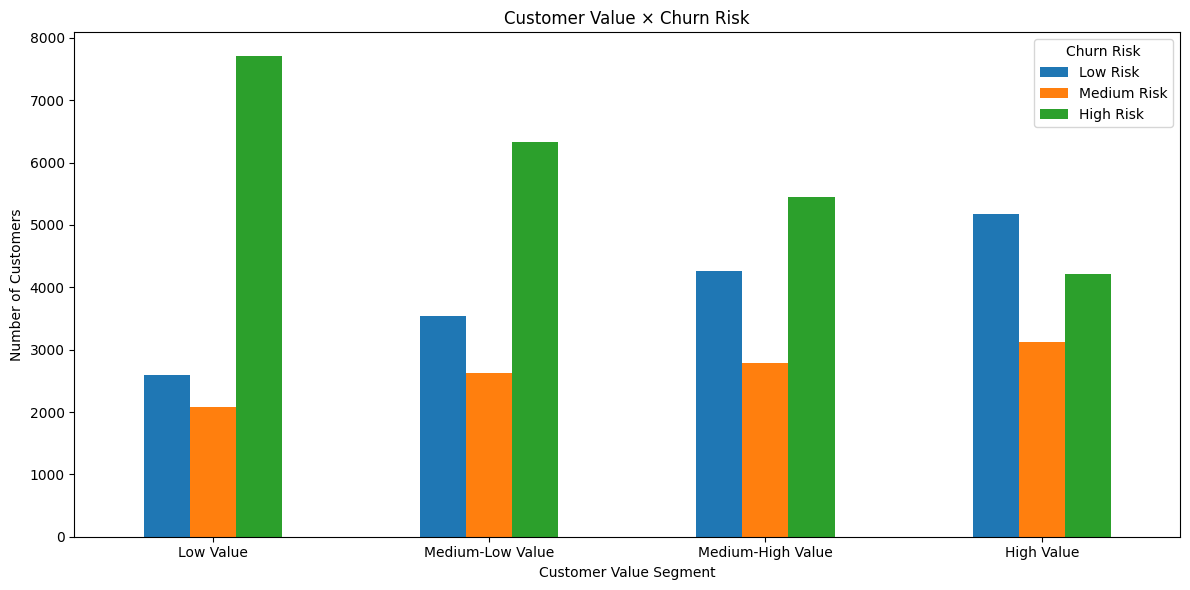

In [ ]:
# STEP 26: VALUE × RISK VISUALIZATION

import matplotlib.pyplot as plt

plot_data = value_risk_matrix.copy()

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Customer Value × Churn Risk")
plt.xlabel("Customer Value Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn Risk")
plt.tight_layout()
plt.show()

In [ ]:
# STEP 27: REVENUE AT RISK

revenue_risk = (
    customer_summary
    .groupby("risk_segment", observed=False)
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("revenue", "sum"),
        average_revenue=("revenue", "mean")
    )
    .reset_index()
)

revenue_risk["revenue_percentage"] = (
    revenue_risk["total_revenue"]
    / customer_summary["revenue"].sum()
    * 100
)

print("=" * 75)
print("REVENUE AT RISK BY CUSTOMER RISK SEGMENT")
print("=" * 75)

print(
    revenue_risk.to_string(
        index=False,
        formatters={
            "total_revenue": "₹{:,.2f}".format,
            "average_revenue": "₹{:,.2f}".format,
            "revenue_percentage": "{:.2f}%".format
        }
    )
)

high_risk_revenue = revenue_risk.loc[
    revenue_risk["risk_segment"] == "High Risk",
    "total_revenue"
].iloc[0]

total_revenue = customer_summary["revenue"].sum()

print("\n" + "=" * 75)
print(f"TOTAL CUSTOMER REVENUE: ₹{total_revenue:,.2f}")
print(f"HIGH-RISK CUSTOMER REVENUE: ₹{high_risk_revenue:,.2f}")
print(
    f"REVENUE ASSOCIATED WITH HIGH-RISK CUSTOMERS: "
    f"{high_risk_revenue / total_revenue * 100:.2f}%"
)
print("=" * 75)

REVENUE AT RISK BY CUSTOMER RISK SEGMENT
risk_segment  customers     total_revenue average_revenue revenue_percentage
    Low Risk      15566 ₹1,357,710,679.00      ₹87,222.84             35.47%
 Medium Risk      10617   ₹873,568,600.00      ₹82,280.17             22.82%
   High Risk      23703 ₹1,596,466,857.00      ₹67,352.95             41.71%

TOTAL CUSTOMER REVENUE: ₹3,827,746,136.00
HIGH-RISK CUSTOMER REVENUE: ₹1,596,466,857.00
REVENUE ASSOCIATED WITH HIGH-RISK CUSTOMERS: 41.71%


In [ ]:
# Create order frequency groups

customer_summary["order_frequency"] = pd.cut(
    customer_summary["total_orders"],
    bins=[0, 1, 3, 6, float("inf")],
    labels=["1 Order", "2–3 Orders", "4–6 Orders", "7+ Orders"]
)

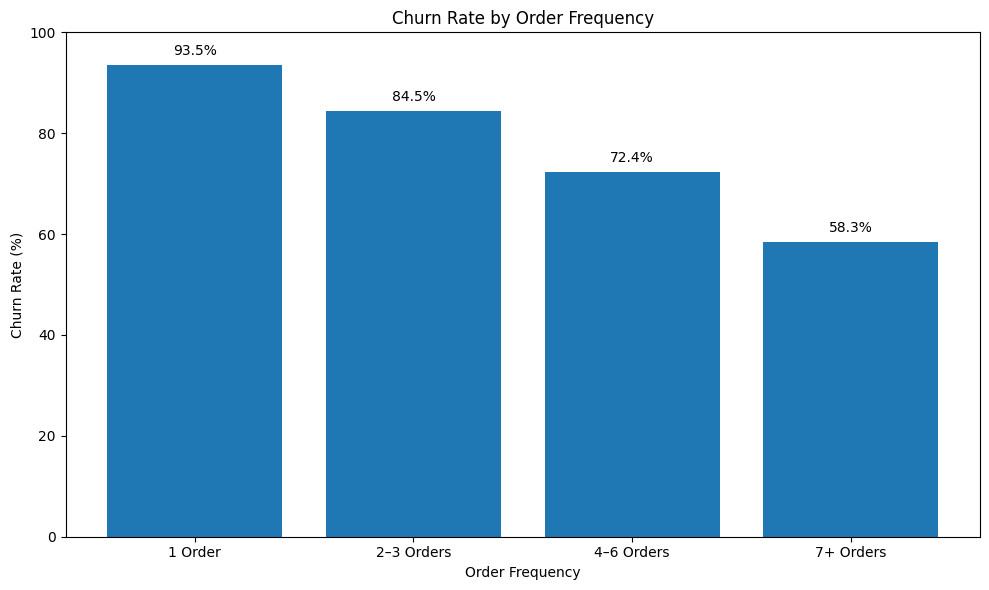

In [ ]:
# STEP 29: CHURN RATE BY ORDER FREQUENCY

order_churn = (
    customer_summary
    .groupby("order_frequency", observed=False)
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum")
    )
    .reset_index()
)

order_churn["churn_rate"] = (
    order_churn["churned_customers"]
    / order_churn["customers"]
    * 100
)

plt.figure(figsize=(10, 6))

plt.bar(
    order_churn["order_frequency"].astype(str),
    order_churn["churn_rate"]
)

plt.title("Churn Rate by Order Frequency")
plt.xlabel("Order Frequency")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(order_churn["churn_rate"]):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

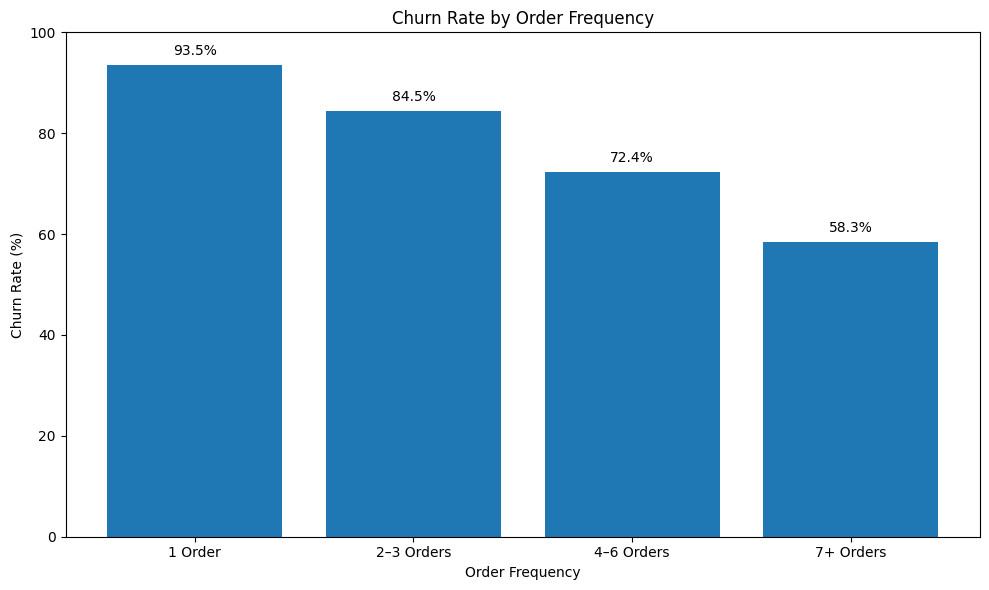

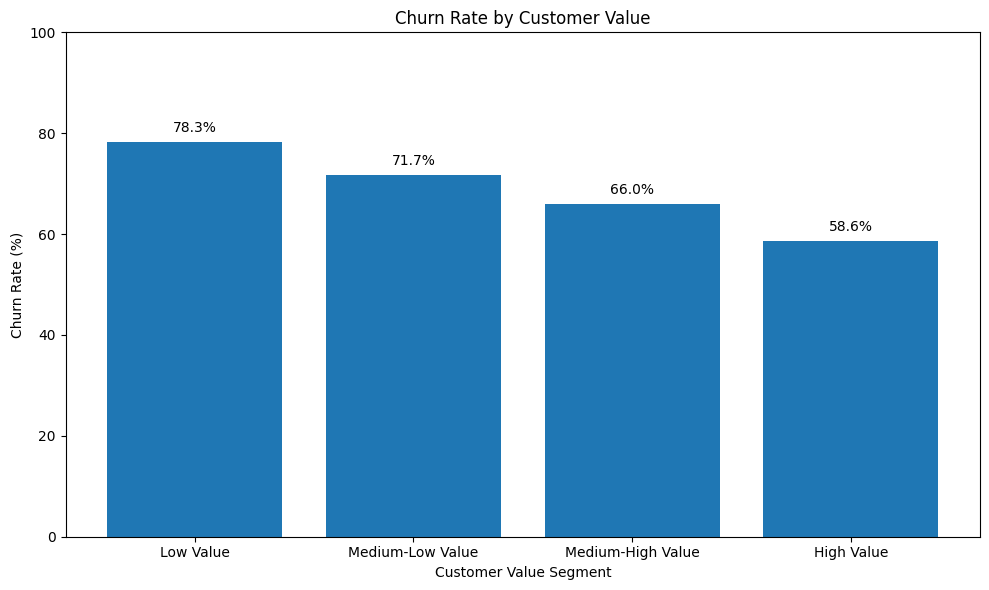

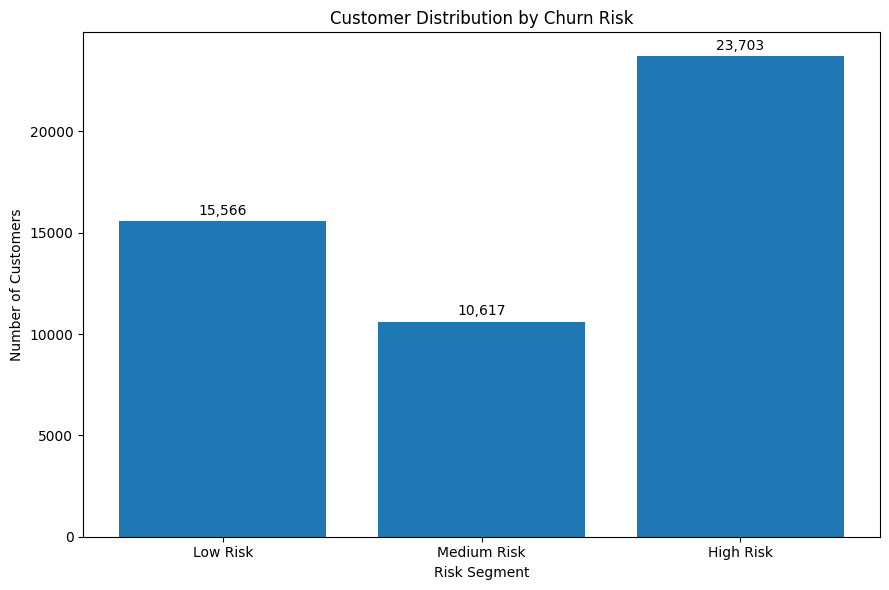

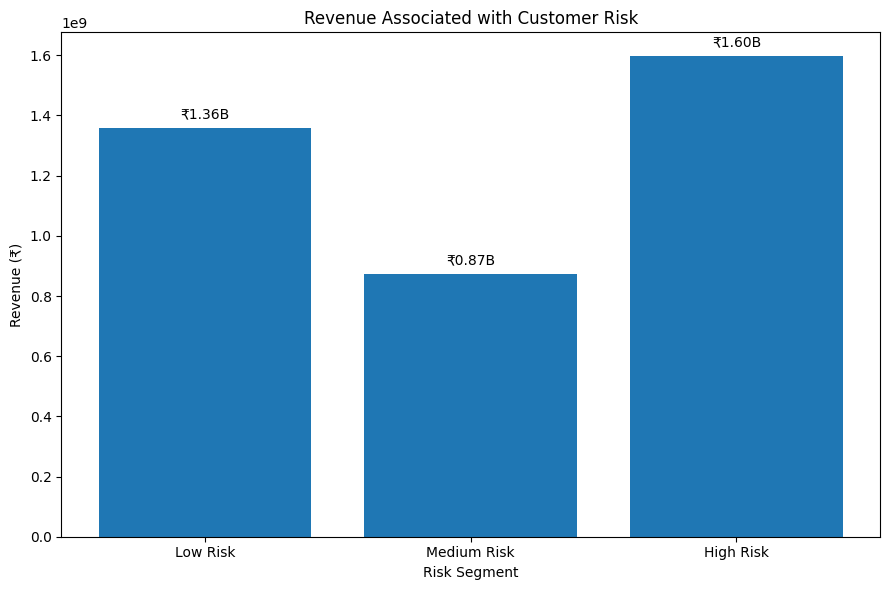

<Figure size 1200x600 with 0 Axes>

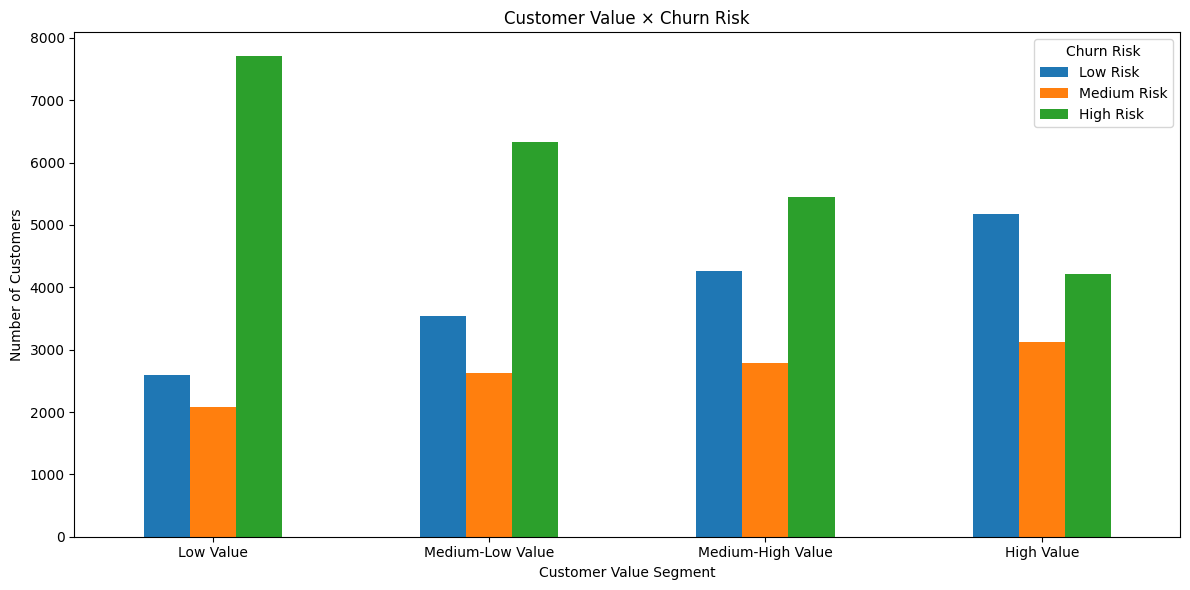

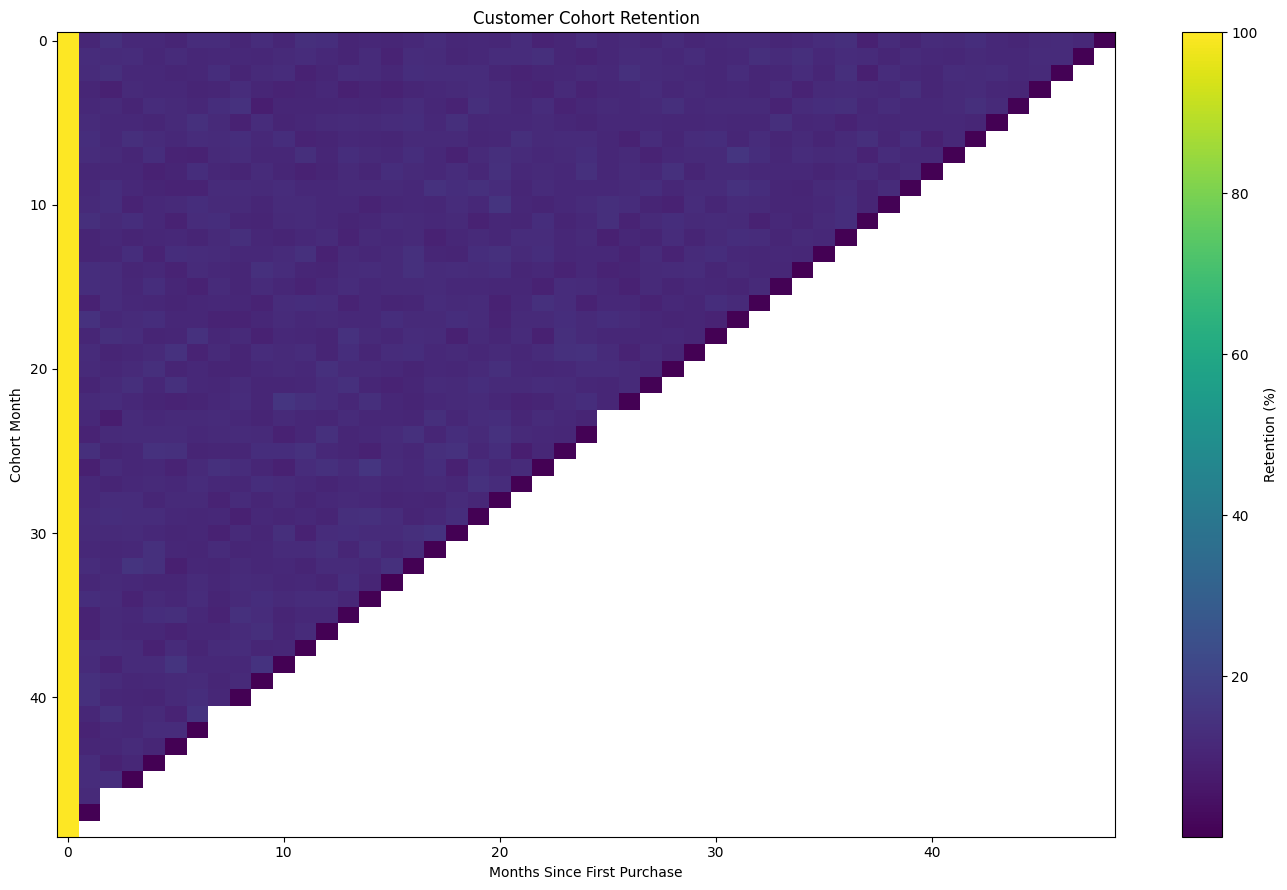

PORTFOLIO ANALYSIS SUMMARY
Total Customers: 50,000
Total Revenue: ₹3,827,746,136.00
Overall Churn Rate: 68.64%
High-Risk Customers: 23,703
High-Risk Customer Revenue: ₹1,596,466,857.00
Revenue Associated with High-Risk Customers: 41.71%
High-Value + High-Risk Customers: 4,208


In [ ]:
# ============================================================
# PORTFOLIO CHARTS — CUSTOMER COHORT & CHURN ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. CHURN RATE BY ORDER FREQUENCY
# ------------------------------------------------------------

order_churn = (
    customer_summary
    .groupby("order_frequency", observed=False)
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum")
    )
    .reset_index()
)

order_churn["churn_rate"] = (
    order_churn["churned_customers"]
    / order_churn["customers"] * 100
)

plt.figure(figsize=(10, 6))

plt.bar(
    order_churn["order_frequency"].astype(str),
    order_churn["churn_rate"]
)

plt.title("Churn Rate by Order Frequency")
plt.xlabel("Order Frequency")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(order_churn["churn_rate"]):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. CHURN RATE BY CUSTOMER VALUE
# ------------------------------------------------------------

value_churn = (
    customer_summary
    .groupby("value_segment", observed=False)
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum")
    )
    .reset_index()
)

value_churn["churn_rate"] = (
    value_churn["churned_customers"]
    / value_churn["customers"] * 100
)

plt.figure(figsize=(10, 6))

plt.bar(
    value_churn["value_segment"].astype(str),
    value_churn["churn_rate"]
)

plt.title("Churn Rate by Customer Value")
plt.xlabel("Customer Value Segment")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(value_churn["churn_rate"]):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. CUSTOMER RISK SEGMENT DISTRIBUTION
# ------------------------------------------------------------

risk_counts = (
    customer_summary["risk_segment"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

plt.figure(figsize=(9, 6))

plt.bar(
    risk_counts.index.astype(str),
    risk_counts.values
)

plt.title("Customer Distribution by Churn Risk")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")

for i, value in enumerate(risk_counts.values):
    plt.text(i, value + 300, f"{value:,}", ha="center")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. REVENUE ASSOCIATED WITH CHURN-RISK SEGMENTS
# ------------------------------------------------------------

revenue_chart = (
    customer_summary
    .groupby("risk_segment", observed=False)["revenue"]
    .sum()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

plt.figure(figsize=(9, 6))

plt.bar(
    revenue_chart.index.astype(str),
    revenue_chart.values
)

plt.title("Revenue Associated with Customer Risk")
plt.xlabel("Risk Segment")
plt.ylabel("Revenue (₹)")

for i, value in enumerate(revenue_chart.values):
    plt.text(
        i,
        value + revenue_chart.max() * 0.02,
        f"₹{value / 1e9:.2f}B",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. CUSTOMER VALUE × CHURN RISK
# ------------------------------------------------------------

value_risk_matrix = pd.crosstab(
    customer_summary["value_segment"],
    customer_summary["risk_segment"]
)

value_risk_matrix = value_risk_matrix.reindex(
    index=[
        "Low Value",
        "Medium-Low Value",
        "Medium-High Value",
        "High Value"
    ],
    columns=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.figure(figsize=(12, 6))

value_risk_matrix.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Customer Value × Churn Risk")
plt.xlabel("Customer Value Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn Risk")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. COHORT RETENTION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(14, 9))

plt.imshow(
    retention_percentage,
    aspect="auto"
)

plt.title("Customer Cohort Retention")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.colorbar(label="Retention (%)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("=" * 70)
print("PORTFOLIO ANALYSIS SUMMARY")
print("=" * 70)

print(f"Total Customers: {len(customer_summary):,}")
print(f"Total Revenue: ₹{customer_summary['revenue'].sum():,.2f}")
print(f"Overall Churn Rate: {customer_summary['churned'].mean() * 100:.2f}%")
print(f"High-Risk Customers: {(customer_summary['risk_segment'] == 'High Risk').sum():,}")

high_risk_revenue = customer_summary.loc[
    customer_summary["risk_segment"] == "High Risk",
    "revenue"
].sum()

print(f"High-Risk Customer Revenue: ₹{high_risk_revenue:,.2f}")
print(
    f"Revenue Associated with High-Risk Customers: "
    f"{high_risk_revenue / customer_summary['revenue'].sum() * 100:.2f}%"
)

high_value_high_risk = customer_summary[
    (customer_summary["value_segment"] == "High Value") &
    (customer_summary["risk_segment"] == "High Risk")
]

print(f"High-Value + High-Risk Customers: {len(high_value_high_risk):,}")

print("=" * 70)

In [ ]:
# STEP 31: EXPORT DATA FOR POWER BI

# Main customer-level dataset
customer_summary.to_csv(
    "customer_analysis.csv",
    index=False
)

# Cohort retention data
retention_percentage.reset_index().to_csv(
    "cohort_retention.csv",
    index=False
)

# Churn by order frequency
order_churn.to_csv(
    "churn_by_order_frequency.csv",
    index=False
)

# Churn by customer value
value_churn.to_csv(
    "churn_by_customer_value.csv",
    index=False
)

# Revenue by risk segment
revenue_risk.to_csv(
    "revenue_by_risk.csv",
    index=False
)

# Value × Risk matrix
value_risk_matrix.reset_index().to_csv(
    "value_risk_matrix.csv",
    index=False
)

print("All Power BI files created successfully!")

print("\nFiles:")
print("1. customer_analysis.csv")
print("2. cohort_retention.csv")
print("3. churn_by_order_frequency.csv")
print("4. churn_by_customer_value.csv")
print("5. revenue_by_risk.csv")
print("6. value_risk_matrix.csv")

All Power BI files created successfully!

Files:
1. customer_analysis.csv
2. cohort_retention.csv
3. churn_by_order_frequency.csv
4. churn_by_customer_value.csv
5. revenue_by_risk.csv
6. value_risk_matrix.csv
